In [71]:
import numpy as np
import pandas as pd
from matplotlib import pylab as plt

ddir = '/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupTFtoOcean/data_analysis/'

metadata_file = ddir+'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)

In [72]:
df_best=pd.read_csv(ddir+'tables/best_ms_method_per_model.csv')
df_best_min_max=pd.read_csv(ddir+'tables/ms_best_min_max.csv')

In [73]:
df_best

,Unnamed: 0,Model,mean-error,method,parameterization,melt_sensetivity_AIS,melt_sensetivity_intercept_AIS,melt_sensetivity_Amundsen,melt_sensetivity_intercept_Amundsen,melt_sensetivity_Ross,melt_sensetivity_intercept_Ross,melt_sensetivity_FilchnerRonne,melt_sensetivity_intercept_FilchnerRonne,melt_sensetivity_Aurora,melt_sensetivity_intercept_Aurora,melt_sensetivity_Wilkes,melt_sensetivity_intercept_Wilkes
0,0,DC_ISSM,1.126875,df_maxbmb,Quad. Non-local,3.940746,-1.694661,8.640169,-3.372736,3.354130,-1.536894,4.269001,-1.984396,6.983680,-2.124761,6.423657,-3.994535
1,1,DOE_MALI_4km,1.542692,df_maxbmb,Quad. Non-local,7.091286,-4.422678,18.827810,-17.018395,4.042975,-1.908087,5.389555,-2.404711,9.581578,-2.970956,10.618707,-7.781417
2,2,DOE_MALI_8km_Ant95,1.609465,df_maxbmb,Quad. Non-local,10.636001,-8.527297,21.835821,-23.217318,4.302845,-1.895368,6.010999,-2.553659,11.298475,-4.911402,13.488096,-10.237464
3,3,DOE_MALI_8km_AntMean,1.336166,df_maxbmb,Quad. Non-local,6.905944,-3.671605,17.703470,-16.183663,4.345924,-2.012370,6.094617,-2.850230,10.741955,-4.673022,11.403571,-8.562308
4,4,IGE_ElmerIce,1.822429,df_maxbmb,PICO,1.887178,0.270598,2.611416,8.705787,1.570026,-0.379978,1.837577,-1.078901,8.152143,0.464576,7.746371,-0.735873
5,5,ILTS_SICOPOLIS,1.855219,df_maxbmb,Quad. Non-local,9.529746,-7.334161,19.867998,-14.139391,4.215458,-1.940084,5.730758,-2.780314,9.565332,-1.560262,11.426381,-7.366425
6,6,LSCE_GRISLI2,1.479912,df_maxbmb,Quad. Non-local,5.442525,-2.596553,17.034515,-12.135003,3.643000,-1.662566,4.935931,-2.318317,7.970280,-1.027697,8.469353,-4.225666
7,7,LSCE_GRISLI,1.517942,df_maxbmb,Quad. Non-local,5.507551,-2.621882,17.728342,-13.573608,3.606178,-1.647675,5.148203,-2.499429,8.673908,-1.482538,9.330892,-5.637042
8,8,NCAR_CISM1,1.399016,df_maxbmb,Quad. Non-local,3.792347,-1.423690,6.875624,-9.698237,3.831562,-1.801018,4.972992,-2.467405,2.365846,-3.200780,5.339243,-3.602602
9,9,NCAR_CISM2,1.702342,df_maxbmb,Quad. Local,5.509823,-2.209888,11.917042,-12.972440,4.581646,-1.519366,6.870203,-2.637447,7.991848,-2.447761,7.707624,-2.205806


### Group by AIS -, regions-mean (Amundsen, FRIS, ROSS and EAST, WEST ) module score


In [74]:
regions = ['AIS',
    'Amundsen',
    'Ross',
    'FilchnerRonne',
    'Aurora',
    'Wilkes'
    ]
index =np.argsort(df_best['melt_sensetivity_AIS'].values)
index = index[::-1]

# regions = df_dils.columns[4:].values.tolist()
# regions = ['AIS', 'Amundsen', 'Ross', 'FilchnerRonne', 'Aurora', 'Wilkes']
# regions_all= regions.copy()
# regions1 = regions[1:]
# regions_all1=regions1.copy()

# experiments = np.unique(df_best["Experiment"])
# df_exp = df_best[df_best['Experiment']== experiments[0]].reset_index(drop=True)
models = df_best.Model.values

# df_best = df_exp.copy()
# df_best['mean-error']=1e15
# df_best = df_best.drop(df_best.columns[0:2],axis=1)
# #df_best = df_best.drop(df_best.columns[1],axis=1)
# df_best = df_best.drop(df_best.columns[1:11],axis=1)
for region in regions:
    df_best[f'melt_sensetivity_{region}']=0
    df_best[f'melt_sensetivity_std_{region}']=0
    df_best[f'melt_sensetivity_min_{region}']=0
    df_best[f'melt_sensetivity_max_{region}']=0
    df_best['calving']=''
    df_best['initialisation']=''
    df_best['resolution']=''
    df_best['meltonpartial']=''
    df_best['icefront']=''

renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3' 

In [75]:
# initialisation
initialisation={'DC_ISSM':'DA', 'DOE_MALI_4km':'DA+', 'DOE_MALI_8km_Ant95':'DA+', 'DOE_MALI_8km_AntMean':'DA+',\
                'IGE_ElmerIce':'DA', 'ILTS_SICOPOLIS':'SP+', 'IMAU_UFEMISM1':'SP+', 'IMAU_UFEMISM2':'SP+', \
                'IMAU_UFEMISM3':'SP+', 'IMAU_UFEMISM4':'SP+', 'LSCE_GRISLI2':'SP+', 'LSCE_GRISLI':'SP+', \
                'NCAR_CISM1':'SP+', 'NCAR_CISM2':'SP+', 'NORCE_CISM3-MAR364-ERA-t1-nonlocal':'SP+', \
                'NORCE_CISM4-MAR364-ERA-t1-nonlocal':'SP+', 'NORCE_CISM5-MAR364-ERA-t1-nonlocal':'SP+', \
                'NORCE_CISM3-MAR364-ERA-t1-local':'SP+', 'NORCE_CISM4-MAR364-ERA-t1-local':'SP+', \
                'NORCE_CISM5-MAR364-ERA-t1-local':'SP+', 'NORCE_CISM2-MAR364-ERA-t1':'SP+', \
                'NORCE_CISM3-MAR364-ERA-t1':'SP+', 'NORCE_CISM4-MAR364-ERA-t1':'SP+', 'NORCE_CISM4-MAR364-JRA-t1':'SP+', \
                'NORCE_CISM5-MAR364-ERA-t1':'SP+', 'PIK_PISM':'SP', 'UCM_Yelmo':'SP+', 'UCSD_ISSM':'DA', \
                'ULB_fETISh-KoriBU1':'DA*', 'ULB_fETISh-KoriBU2':'DA*', 'UNN_Ua':'DA', 'UTAS_ElmerIce':'DA',\
                'VUB_AISMPALEO':'SP', 'VUW_PISM1':'SP', 'VUW_PISM1_s1':'SP', 'VUW_PISM1_s2':'SP', 'VUW_PISM1_s3':'SP',\
                'VUW_PISM1_s4':'SP','VUW_PISM2':'SP', 'VUW_PISM2_s1':'SP', 'VUW_PISM2_s2':'SP', 'VUW_PISM2_s3':'SP', 'VUW_PISM2_s4':'SP'}

for i,Mod in enumerate(df_best['Model']):
    df_best.loc[i, 'initialisation'] = initialisation[Mod]

In [76]:
# calving group
calving_group={'DC_ISSM':2, 'DOE_MALI_4km':2, 'DOE_MALI_8km_Ant95':2, 'DOE_MALI_8km_AntMean':2,\
                'IGE_ElmerIce':2, 'ILTS_SICOPOLIS':2, 'IMAU_UFEMISM1':2, 'IMAU_UFEMISM2':2, \
                'IMAU_UFEMISM3':2, 'IMAU_UFEMISM4':2, 'LSCE_GRISLI2':1, 'LSCE_GRISLI':1, \
                'NCAR_CISM1':2, 'NCAR_CISM2':2, 'NORCE_CISM3-MAR364-ERA-t1-nonlocal':2, \
                'NORCE_CISM4-MAR364-ERA-t1-nonlocal':2, 'NORCE_CISM5-MAR364-ERA-t1-nonlocal':2, \
                'NORCE_CISM3-MAR364-ERA-t1-local':2, 'NORCE_CISM4-MAR364-ERA-t1-local':2, \
                'NORCE_CISM5-MAR364-ERA-t1-local':2, 'NORCE_CISM2-MAR364-ERA-t1':2, \
                'NORCE_CISM3-MAR364-ERA-t1':2, 'NORCE_CISM4-MAR364-ERA-t1':2, 'NORCE_CISM4-MAR364-JRA-t1':2, \
                'NORCE_CISM5-MAR364-ERA-t1':2, 'PIK_PISM':1, 'UCM_Yelmo':1, 'UCSD_ISSM':3, \
                'ULB_fETISh-KoriBU1':3, 'ULB_fETISh-KoriBU2':2, 'UNN_Ua':2, 'UTAS_ElmerIce':2,\
                'VUB_AISMPALEO':2, 'VUW_PISM1':1, 'VUW_PISM1_s1':1, 'VUW_PISM1_s2':1, 'VUW_PISM1_s3':1,\
                'VUW_PISM1_s4':1,'VUW_PISM2':1, 'VUW_PISM2_s1':1, 'VUW_PISM2_s2':1, 'VUW_PISM2_s3':1, 'VUW_PISM2_s4':1}

for i,Mod in enumerate(df_best['Model']):
    df_best.loc[i, 'calving'] = calving_group[Mod]

In [77]:
# melt on partial
mop_group={'DC_ISSM':'SG', 'DOE_MALI_4km':'FC', 'DOE_MALI_8km_Ant95':'FC', 'DOE_MALI_8km_AntMean':'FC',\
           'IGE_ElmerIce':'no', 'ILTS_SICOPOLIS':'FC', 'IMAU_UFEMISM1':'FC', 'IMAU_UFEMISM2':'FC', \
           'IMAU_UFEMISM3':'FC', 'IMAU_UFEMISM4':'FC', 'LSCE_GRISLI2':'no', 'LSCE_GRISLI':'FC', \
           'NCAR_CISM1':'SG', 'NCAR_CISM2':'SG', 'NORCE_CISM3-MAR364-ERA-t1-nonlocal':'FC', \
           'NORCE_CISM4-MAR364-ERA-t1-nonlocal':'FC', 'NORCE_CISM5-MAR364-ERA-t1-nonlocal':'FC', \
           'NORCE_CISM3-MAR364-ERA-t1-local':'FC', 'NORCE_CISM4-MAR364-ERA-t1-local':'FC', \
           'NORCE_CISM5-MAR364-ERA-t1-local':'FC', 'NORCE_CISM2-MAR364-ERA-t1':'FC', \
           'NORCE_CISM3-MAR364-ERA-t1':'FC', 'NORCE_CISM4-MAR364-ERA-t1':'FC', 'NORCE_CISM4-MAR364-JRA-t1':'FC', \
           'NORCE_CISM5-MAR364-ERA-t1':'FC', 'PIK_PISM':'FC', 'UCM_Yelmo':'SG', 'UCSD_ISSM':'SG', \
           'ULB_fETISh-KoriBU1':'no', 'ULB_fETISh-KoriBU2':'no', 'UNN_Ua':'no', 'UTAS_ElmerIce':'SG',\
           'VUB_AISMPALEO':'n/a', 'VUW_PISM1':'no', 'VUW_PISM1_s1':'no', 'VUW_PISM1_s2':'no', 'VUW_PISM1_s3':'no',\
           'VUW_PISM1_s4':'no','VUW_PISM2':'yes', 'VUW_PISM2_s1':'yes', 'VUW_PISM2_s2':'yes', 'VUW_PISM2_s3':'yes', 'VUW_PISM2_s4':'yes'}

for i,Mod in enumerate(df_best['Model']):
    df_best.loc[i, 'meltonpartial'] = mop_group[Mod]

In [78]:
clname = df_best.columns
i_clname = np.arange(0,clname.size)

for l,df in enumerate(df_best):
    
    for i,Mod in enumerate(models):
        #iterate though model names
        best = 1e15
        dfmodel = df_best[df_best['Model']== Mod].copy()

        if df_best.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
            nmname = renamer[df_best.iloc[i].Model]
        else:
            nmname = Mod
        
        df_info_model = df_info[df_info['fileID']==nmname]
        #df_info_model_exp = df_info_model[df_info_model['Experiment']==experiments[0]]
        
        # set resolution
        resolution = df_info_model['Resolution'].values[0]
        df_best.loc[i, 'resolution'] = resolution
        
#regions_all.append('mean-error')

## Main Figure

In [79]:
colors = ['black','#882255', '#44AA99', '#117733', '#332288', '#DDCC77']


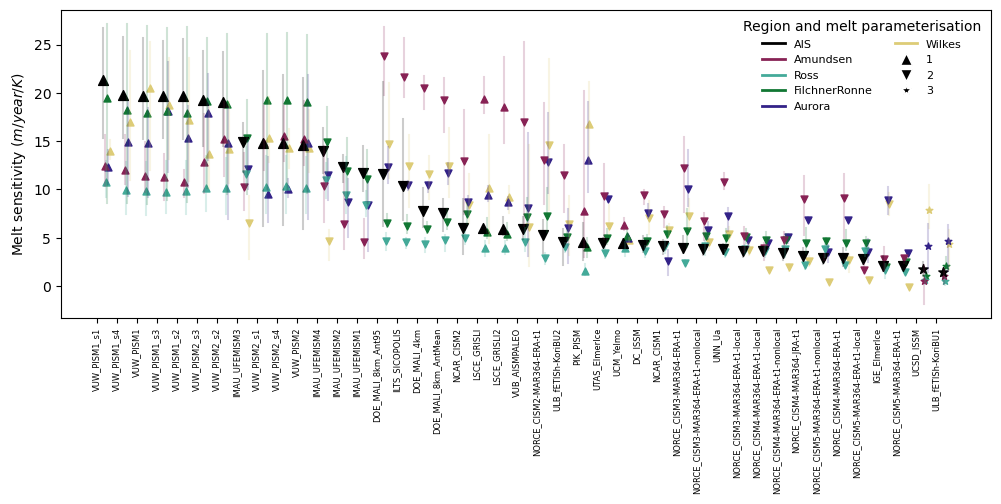

In [87]:
to_m_k_a = 10**3/917 #t into kg into m3
marker_key = 'calving'
param_u =np.unique(df_best[marker_key])
marker_u = ['^','v','*','s','P','p']
dic_marker = {}

for i,key in enumerate(param_u):
    dic_marker[key]= marker_u[i]
markers = []
marker_nomodel=[]
msk = df_best.Model.values != 'VUW_PISM2_s1'
for key in df_best[marker_key][index]:
    markers.append(dic_marker[key])

for key in df_best[marker_key][msk]:
    marker_nomodel.append(dic_marker[key])

f,ax = plt.subplots(1,1,figsize =(12,4))
# colors = ['black', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i,region in enumerate(regions[::-1]):
    y = df_best_min_max[f'melt_sensetivity_{region}'].values[index]
    y_err_lower = df_best_min_max[f'min_melt_sensetivity_{region}'].values[index]
    y_err_upper =df_best_min_max[f'max_melt_sensetivity_{region}'].values[index] 
    xall = np.arange(len(index))*8+5 -0.5 *i
    
    for j, yl in enumerate(y_err_lower):
        yu = y_err_upper[j]
        ym = y[j]
        x=xall[j]
        if i == 5:
            plt.scatter(x,ym*to_m_k_a ,marker=markers[j],  color=colors[::-1][i],s = 50)
        else:
            plt.scatter(x,ym*to_m_k_a,marker=markers[j],  color=colors[::-1][i],s=25)
        plt.plot([x,x],[yl*to_m_k_a,yu*to_m_k_a] ,  color=colors[::-1][i],alpha =0.2)

ax.set_xticks(np.arange(len(index))*8)
ax.set_xticklabels(df_best['Model'].values[index], rotation = 90,fontsize =6)
ax.set_ylabel('Melt sensitivity ($m/year/K$)')

# Legend for markers
marker_handles = [plt.Line2D([0], [0], marker=marker_u[i], color='w', 
                             markerfacecolor='k', markersize=8, 
                             label=param_u[i]) 
                  for i in range(len(param_u))]

# Legend for colors
color_handles = [plt.Line2D([0], [0], color=colors[i], lw=2, 
                            label=region) 
                 for i, region in enumerate(regions)]
# Combine marker and color legends into one
combined_handles = color_handles + marker_handles
combined_labels = regions + param_u.tolist()

# Add the combined legend
ax.legend(handles=combined_handles, labels=combined_labels, title="Region and melt parameterisation", 
          loc='upper right', bbox_to_anchor=(1, 1), ncol=2, frameon=False, fontsize = 8)

# Save the figure with tight bounding box
f.savefig(f'figs/paper/melt_sensitivity_AIS_{marker_key}.pdf', bbox_inches='tight')
f.savefig(f'figs/paper/melt_sensitivity_AIS_{marker_key}.jpeg', bbox_inches='tight')
#f.savefig('figs/paper/melt_sensitivity_region_m_K_a.pdf', bbox_inches='tight')
#f.savefig('figs/paper/melt_sensitivity_region_m_K_a.jpeg', bbox_inches='tight')
#f.savefig('figs/paper/Fig3.pdf', bbox_inches='tight')
#f.savefig('figs/paper/Fig3.jpeg', bbox_inches='tight')


In [7]:
df_best_min_max_alpha = df_best_min_max.sort_values(by='Model', ascending=True)

In [8]:
from docx import Document


# Example DataFrame
data = {
    'MS AIS': np.round(df_best_min_max_alpha['melt_sensetivity_AIS'].values*to_m_k_a,1),
    'MS MIN': np.round(df_best_min_max_alpha['min_melt_sensetivity_AIS'].values*to_m_k_a),
    'MS MAX': np.round(df_best_min_max_alpha['max_melt_sensetivity_AIS'].values*to_m_k_a)
}
df = pd.DataFrame(data)

# Create a Word document
doc = Document()

# Add a table
table = doc.add_table(rows=1, cols=len(df.columns))

# Add header row
hdr_cells = table.rows[0].cells
for i, col_name in enumerate(df.columns):
    hdr_cells[i].text = col_name

# Add the DataFrame rows to the table
for _, row in df.iterrows():
    row_cells = table.add_row().cells
    for i, value in enumerate(row):
        row_cells[i].text = str(value)

# Save the Word document
doc.save('tables/mss_table.docx')


ModuleNotFoundError: No module named 'docx'

In [10]:
df_best_min_max_alpha['melt_sensetivity_AIS'].values.to_m_k_a

array([ 4.29743285,  7.73313613, 11.59869287,  7.53101805,  2.0579909 ,
       10.39230794, 11.66600928, 12.27574305, 14.92229804, 13.98540953,
        6.00605348,  5.93514183,  4.13560207,  6.00853102,  5.31155102,
        3.98409591,  3.65216514,  3.88471146,  2.93961047,  3.61736529,
        3.44085972,  3.14674987,  2.04264589,  2.81109635,  2.94237693,
        4.53571032,  4.43796988,  1.81899681,  1.4652857 ,  4.53997617,
        3.85938045,  4.47947815,  5.9220353 , 19.68471432, 21.28958362,
       19.62737658, 19.64205454, 19.7509699 , 14.57983002, 14.823373  ,
       19.08466922, 19.25600514, 14.7899301 ])